In [2]:
#TP4

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

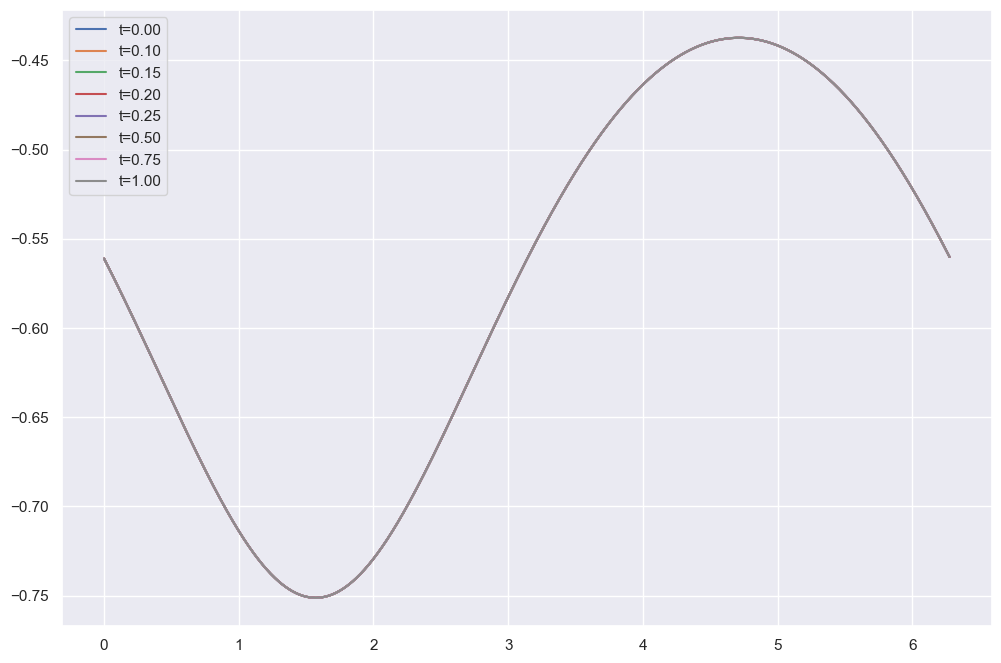

In [4]:
#Exercice 8:
#On veut résoudre le problème d'evolution: u_t - u_xx + u = -1/(2-sin(x))
#on prend de condition initiale la solution du problème 7 du TP3 (IC au dessus)
#on a periodicité en X, pas en T
#on note que du_k/dt = (1-k**2)*u_k - f_k, ou f_k sont les coefficients de f, et on trouve une EDO
#à résoudre pour chaque k: du_k/dt = -(1+k**2)*u_k - f_k, avec u_k(0) = IC[k]

#avec un calcul on trouve que la solution de l'edo est Ce^(At)+B,
#où A = -(1+k**2), B = f_k, et C = IC_k - f_k/(1+k**2)
#donc la solution est u_k(t) = (IC[k] - F[k]/(1+k**2))*np.exp(-(1+k**2)*t) + F[k]/(1+k**2)

def f(x):
    return -1/(2-np.sin(x))

T = np.linspace(0,1,200)
X = np.linspace(0,np.pi*2,1000, endpoint=False)
N = len(X)
k = np.fft.fftfreq(N,1/N)
k = np.fft.fftshift(k)

F = np.fft.fft(f(X))/N
F = np.fft.fftshift(F)
IC = np.fft.fft(-f(X))/N
IC = np.fft.fftshift(IC)/(-1-k**2)

Sol = [(IC - F/(1+k**2))*np.exp(-(1+k**2)*t) + F/(1+k**2) for t in T]

#Montrons la solution à différents instants de temps
fig, ax = plt.subplots(figsize=(12,8))
for i in [0, 20, 30, 40, 50, 100, 150, 199]:
    Sol[i] = np.fft.ifftshift(Sol[i]*N)
    u = np.real(np.fft.ifft(Sol[i]))
    ax.plot(X,u,label=f"t={T[i]:.2f}")

ax.legend()
plt.show()


#on conclut que la solution converge vers la solution stationnaire, 
#qui est la solution du problème 7 du TP3, c'est à dire u(x) = 1/(2-sin(x))


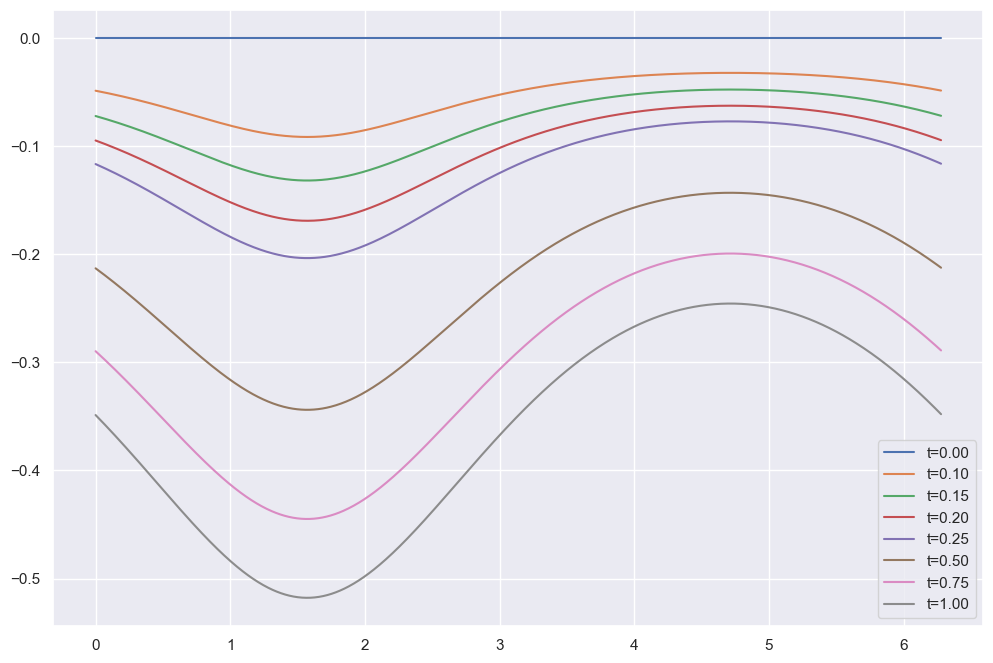

In [5]:
#On reprend le calcul avec une differente condition initiale, par exemple u(x,0) = 0
IC = np.zeros(N)
Sol = [(IC - F/(1+k**2))*np.exp(-(1+k**2)*t) + F/(1+k**2) for t in T]
fig, ax = plt.subplots(figsize=(12,8))
for i in [0, 20, 30, 40, 50, 100, 150, 199]:
    Sol[i] = np.fft.ifftshift(Sol[i])
    u = np.real(np.fft.ifft(Sol[i]*N))
    ax.plot(X,u,label=f"t={T[i]:.2f}")
ax.legend()
plt.show()


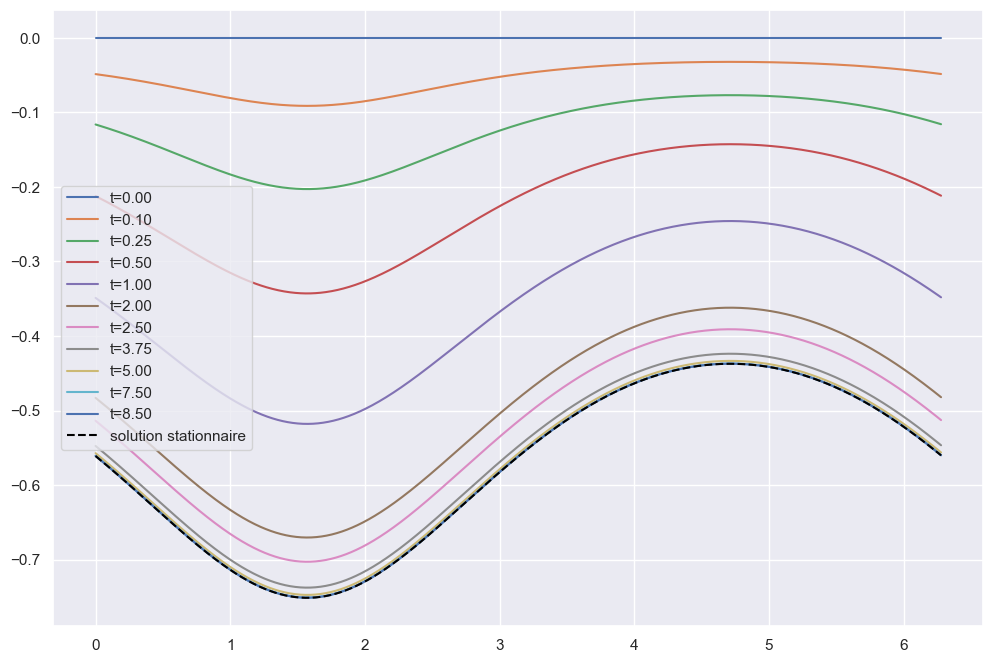

In [6]:
#Si on met cette condition initiale avec T=100, on trouve que la 
#solution est déjà très proche de la solution stationnaire

T = np.linspace(0,10,2000)

Sol = [(IC - F/(1+k**2))*np.exp(-(1+k**2)*t) + F/(1+k**2) for t in T]
fig, ax = plt.subplots(figsize=(12,8))
for i in [0, 20, 50, 100, 200, 400, 500, 750, 1000, 1500, 1700]:
    Sol[i] = np.fft.ifftshift(Sol[i])
    u = np.real(np.fft.ifft(Sol[i]*N))
    ax.plot(X,u,label=f"t={T[i]:.2f}")
#on répresente la solution stationnaire
Sta = np.real(np.fft.ifft(np.fft.fftshift(F/(1+k**2)*N)))
ax.plot(X,Sta,label="solution stationnaire", linestyle="--", color="black")
ax.legend()
plt.show() 


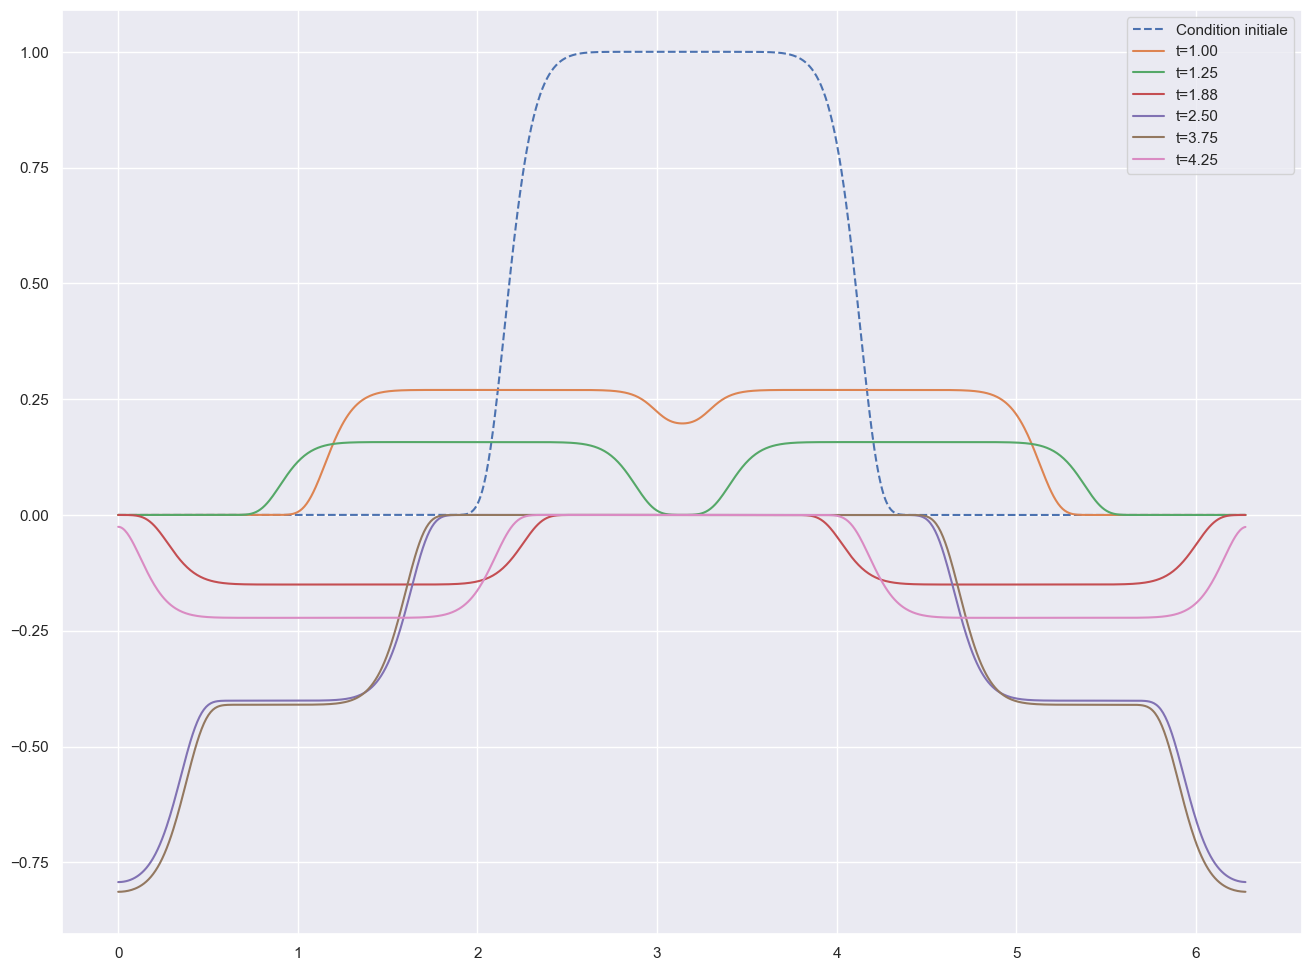

In [23]:
#Exercice 9:
#On veut résoudre le problème de l'equation des ondes: u_tt - u_xx = 0
#avec la condition initiale u(x,0) = exp(-(x-pi)**10) et du_t(x,0) = 0

#Si on part de que si u(x,t) = sum_k u_k(t)*exp(ikx), alors on trouve que du_tt = -k**2*u_k,
#on trouve une EDO du second ordre pour chaque k: du_tt = -k**2*u_k, avec u_k(0) = IC[k], du_t(0) = 0
#si on résout l'EDO, on trouve que la solution est u_k(t) = C*exp(ikt) - C*exp(-ikt), avec C = IC[k]/2
#si on considère la solution réelle, on trouve u_k(t) = C_k*cos(kt) et C_k = IC[k]
#donc la solution est u_k(t) = IC[k]*cos(kt)

def cond_ini(x):
    return np.exp(-(x-np.pi)**10)

T = np.linspace(0,5,2000)
X = np.linspace(0,2*np.pi,1000, endpoint=False)
N = len(X)

IC = np.fft.fft(cond_ini(X))/N
IC = np.fft.fftshift(IC)
k = np.arange(-N/2+1, N/2+1)

CoeffSol = [IC*np.cos(k*t) for t in T]

fig, ax = plt.subplots(figsize=(16,12))
ax.plot(X, np.real(np.fft.ifft(np.fft.ifftshift(IC*N))), linestyle="--", label="Condition initiale")
for i in [400, 500, 750, 1000, 1500, 1700]:
    CoeffSol[i] = np.fft.ifftshift(CoeffSol[i])
    u = np.real(np.fft.ifft(CoeffSol[i]*N))
    ax.plot(X,u,label=f"t={T[i]:.2f}")
ax.legend()
plt.show()







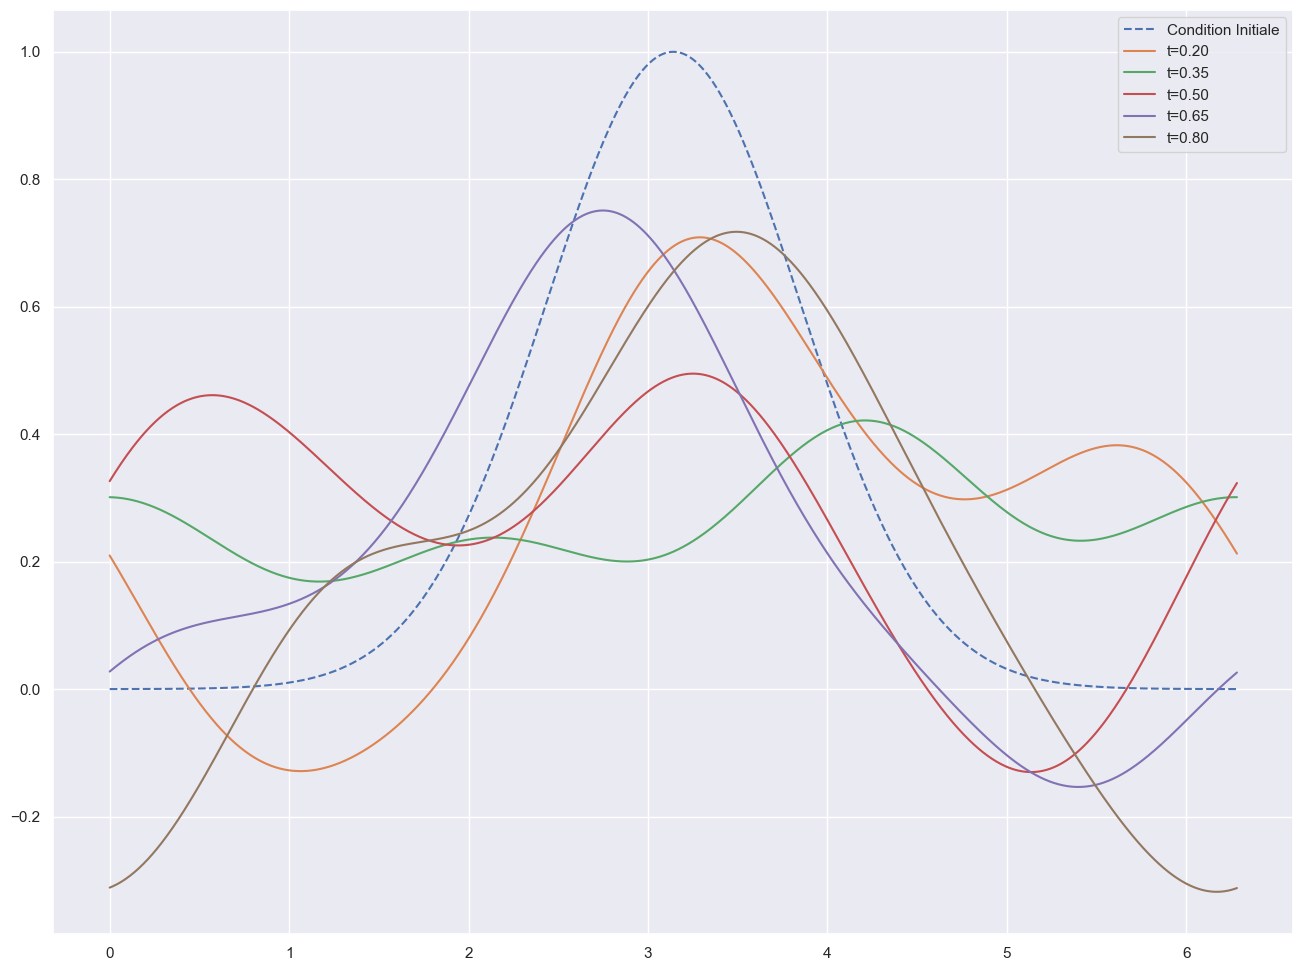

In [35]:
#Exercice 10:
#On veut résoudre le problème de l'Équation d'Airy: u_t + u_xxx = 0
#avec la condition initiale u(x,0) = exp(-(x-pi)**2)
#on trouve que du_k/dt = -ik**3*u_k, avec u_k(0) = IC[k]
#on trouve que la solution de l'EDO est u_k(t) = IC[k]*exp(-ik**3*t)

def cond_ini(x):
    return np.exp(-(x-np.pi)**2)

T = np.linspace(0,1,1000)
X = np.linspace(0,2*np.pi,1000)
N = len(X)
k = np.arange(-N/2+1, N/2+1)

IC = np.fft.fft(cond_ini(X))/N
IC = np.fft.fftshift(IC)

CoeffSol = [IC*np.exp(-1j*k**3 * t) for t in T]

fig, ax = plt.subplots(figsize=(16,12))
ax.plot(X, cond_ini(X), linestyle='--', label="Condition Initiale")
for i in [200, 350, 500, 650, 800]:
    CoeffSol[i] = np.fft.ifftshift(CoeffSol[i])
    sol_i = np.fft.ifft(CoeffSol[i]*N)
    ax.plot(X, sol_i, label=f"t={T[i]:.2f}")
ax.legend()
plt.show()



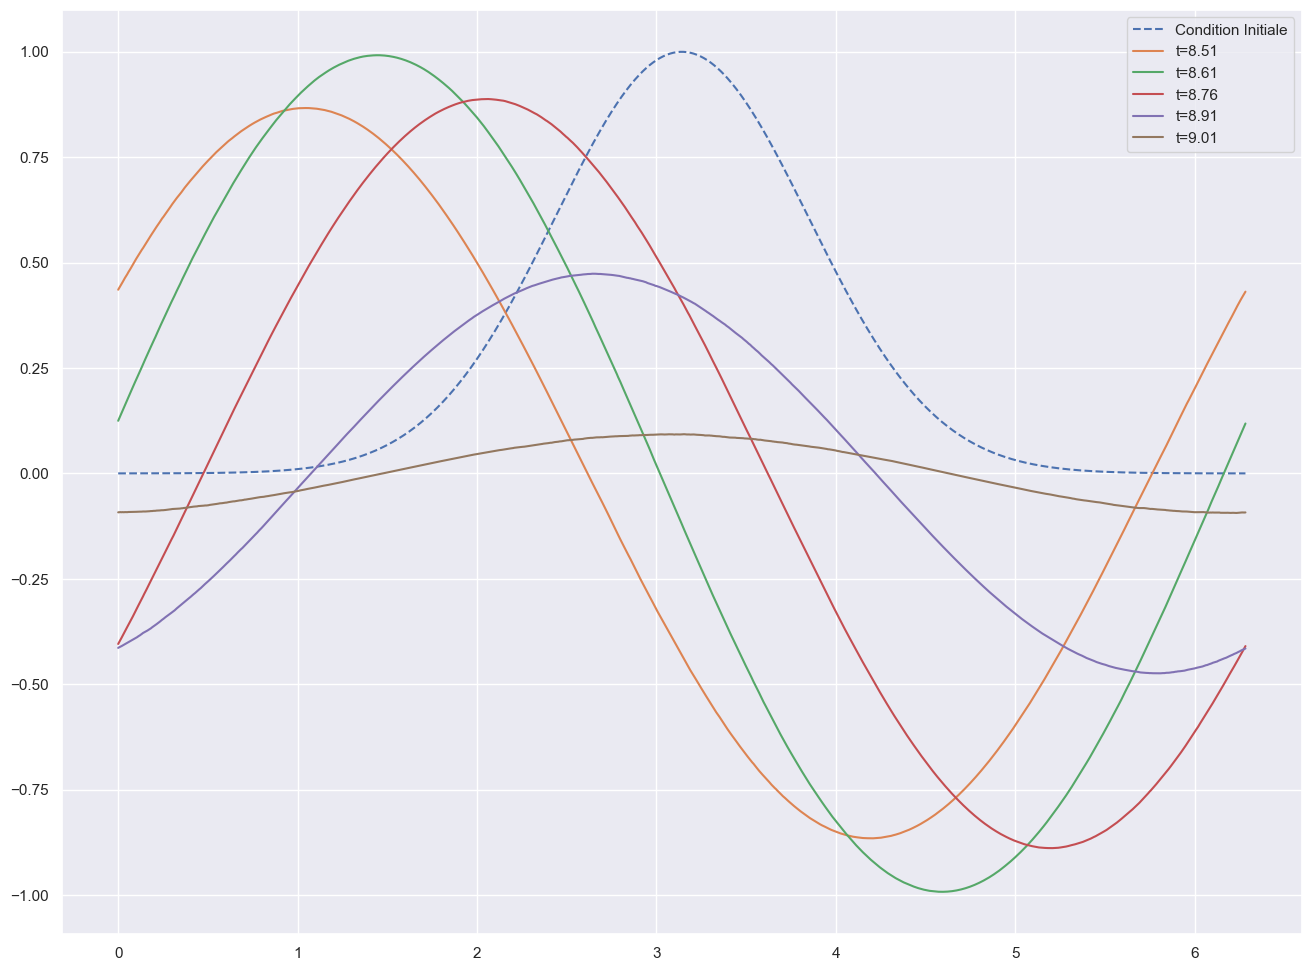

In [43]:
#On répete le même processus mais pour les conditions initiales sin(x) et sin(2x)

def cond_ini1(x):
    return np.sin(x)

T = np.linspace(0,10,1000)
X = np.linspace(0,2*np.pi,1000)
N = len(X)
k = np.arange(-N/2+1, N/2+1)

IC = np.fft.fft(cond_ini1(X))/N
IC = np.fft.fftshift(IC)

CoeffSol = [IC*np.exp(-1j*k**3 * t) for t in T]

fig, ax = plt.subplots(figsize=(16,12))
ax.plot(X, cond_ini(X), linestyle='--', label="Condition Initiale")
for i in [850, 860, 875, 890, 900]:
    CoeffSol[i] = np.fft.ifftshift(CoeffSol[i])
    sol_i = np.fft.ifft(CoeffSol[i]*N)
    ax.plot(X, sol_i, label=f"t={T[i]:.2f}")
ax.legend()
plt.show()


c:\Users\polti\anaconda3\envs\entorn-obert\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\polti\anaconda3\envs\entorn-obert\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


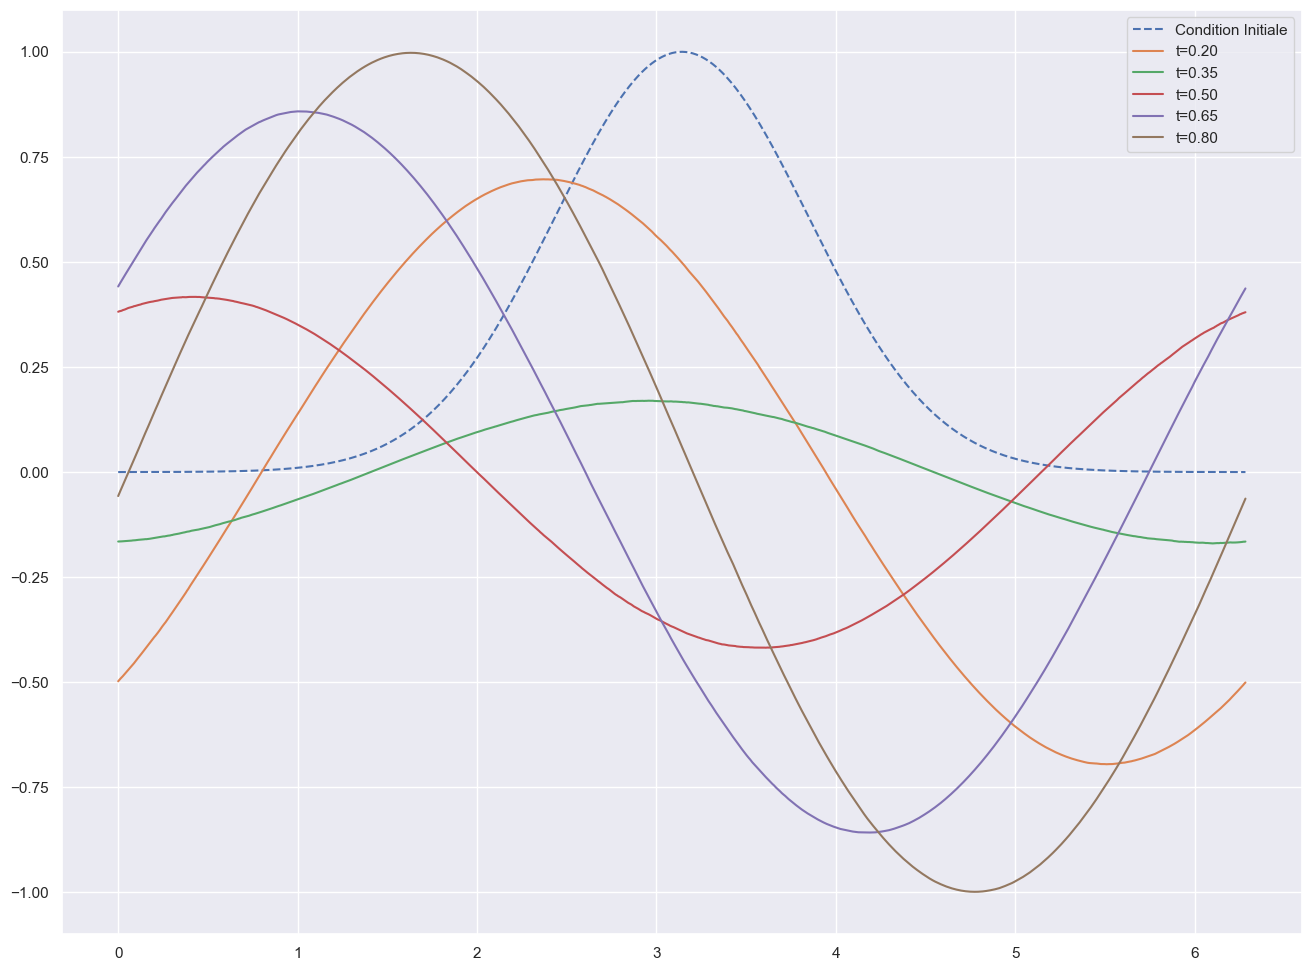

In [38]:
def cond_ini2(x):
    return np.sin(2*x)

T = np.linspace(0,1,1000)
X = np.linspace(0,2*np.pi,1000)
N = len(X)
k = np.arange(-N/2+1, N/2+1)

IC = np.fft.fft(cond_ini1(X))/N
IC = np.fft.fftshift(IC)

CoeffSol = [IC*np.exp(-1j*k**3 * t) for t in T]

fig, ax = plt.subplots(figsize=(16,12))
ax.plot(X, cond_ini(X), linestyle='--', label="Condition Initiale")
for i in [200, 350, 500, 650, 800]:
    CoeffSol[i] = np.fft.ifftshift(CoeffSol[i])
    sol_i = np.fft.ifft(CoeffSol[i]*N)
    ax.plot(X, sol_i, label=f"t={T[i]:.2f}")
ax.legend()
plt.show()